# Khang Tran Homework 09 Serverless
## Preparing the image

In [1]:
from io import BytesIO
from urllib import request
from PIL import Image
import numpy as np

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

In [2]:
import onnxruntime as ort

session = ort.InferenceSession("hair_classifier_v1.onnx")
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
output_name

'output'

## Question 1

To be able to use this model, we need to know the name of the input and output nodes. 

What's the name of the output:

* `output`
* `sigmoid`
* `softmax`
* `prediction`

In [3]:
import onnx

model = onnx.load("hair_classifier_v1.onnx")
graph = model.graph

model.graph.output

[name: "output"
type {
  tensor_type {
    elem_type: 1
    shape {
      dim {
        dim_param: "s77"
      }
      dim {
        dim_value: 1
      }
    }
  }
}
metadata_props {
  key: "pkg.torch.export.graph_signature.OutputSpec.kind"
  value: "USER_OUTPUT"
}
metadata_props {
  key: "pkg.torch.onnx.original_node_name"
  value: "linear_1"
}
]

In [4]:
model.graph.input

[name: "input"
type {
  tensor_type {
    elem_type: 1
    shape {
      dim {
        dim_param: "s77"
      }
      dim {
        dim_value: 3
      }
      dim {
        dim_value: 200
      }
      dim {
        dim_value: 200
      }
    }
  }
}
metadata_props {
  key: "pkg.torch.export.graph_signature.InputSpec.kind"
  value: "USER_INPUT"
}
metadata_props {
  key: "pkg.torch.export.graph_signature.InputSpec.persistent"
  value: "None"
}
metadata_props {
  key: "pkg.torch.onnx.original_node_name"
  value: "x"
}
]

Netron inside the terminal: netron hair_classifier_v1.onnx

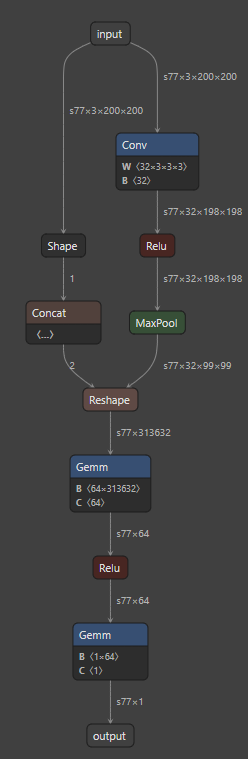

## Question 2: Target size

Let's download and resize this image: 

https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg

Based on the previous homework, what should be the target size for the image?

* 64x64
* 128x128
* 200x200
* 256x256


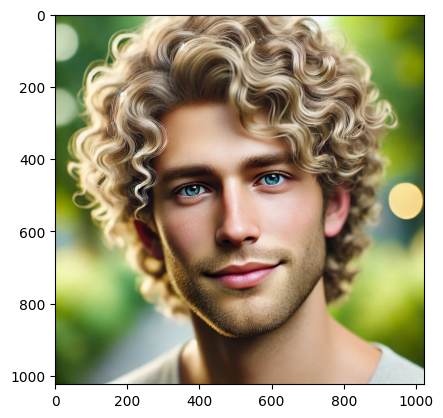

In [5]:
url = "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg"
img = download_image(url)   # using your function
img.save("hair_test_image.jpeg")
import matplotlib.pyplot as plt
plt.imshow(img)

## Question 3

Now we need to turn the image into numpy array and pre-process it. 

> Tip: Check the previous homework. What was the pre-processing 
> we did there?

After the pre-processing, what's the value in the first pixel, the R channel?

* -10.73
* -1.073
* 1.073
* 10.73

In [6]:
import torchvision.transforms as transforms

train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])
img_t = train_transforms(img)
img_t

tensor([[[-1.0562, -1.0733, -1.0562,  ..., -1.0390, -1.1247, -1.1760],
         [-1.0219, -1.0048, -0.9705,  ..., -1.0048, -1.0904, -1.1760],
         [-0.9705, -0.9534, -0.8849,  ..., -1.0219, -1.0904, -1.1760],
         ...,
         [-1.6727, -1.6213, -1.5528,  ...,  1.6838,  1.6667,  1.7180],
         [-1.6727, -1.6555, -1.5699,  ...,  1.7009,  1.6838,  1.7009],
         [-1.6727, -1.6898, -1.6213,  ...,  1.6838,  1.7180,  1.7352]],

        [[-0.1975, -0.1625, -0.1450,  ..., -0.4776, -0.5301, -0.6001],
         [-0.1625, -0.1450, -0.1275,  ..., -0.4951, -0.5651, -0.6176],
         [-0.1099, -0.1099, -0.0924,  ..., -0.4951, -0.5826, -0.6352],
         ...,
         [-1.1604, -1.0903, -1.0028,  ...,  2.0084,  1.9909,  2.0434],
         [-1.1779, -1.1078, -1.0378,  ...,  2.0259,  2.0259,  2.0959],
         [-1.2129, -1.1604, -1.0903,  ...,  2.0259,  2.0784,  2.1134]],

        [[-1.4036, -1.3513, -1.2816,  ..., -1.7870, -1.7696, -1.7522],
         [-1.3164, -1.2816, -1.2119,  ..., -1

## Question 4

Now let's apply this model to this image. What's the output of the model?

* 0.09
* 0.49
* 0.69
* 0.89

In [ ]:
img_hw = prepare_image(img, target_size=(200, 200))
img_hw = train_transforms(img_hw)
img_hw = np.expand_dims(img_hw, axis=0) 
session.run([output_name], {input_name: img_hw})

[array([[0.09156641]], dtype=float32)]

## Question 5

Download the base image `agrigorev/model-2025-hairstyle:v1`. You can do it with [`docker pull`](https://docs.docker.com/engine/reference/commandline/pull/).

So what's the size of this base image?

* 88 Mb
* 208 Mb
* 608 Mb
* 1208 Mb

In [ ]:
!docker images

REPOSITORY                       TAG       IMAGE ID       CREATED      SIZE
agrigorev/model-2025-hairstyle   v1        4528ad1525d5   3 days ago   608MB


## Question 6
Now run the container locally.

Score this image: https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg

What's the output from the model?

* -1.0
* -0.10
* 0.10
* 1.0

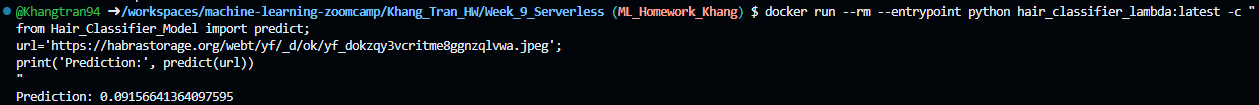